<a href="https://colab.research.google.com/github/kavinkumarManielayaperumal/Toy-Model-for-Gaussian-Mixture-in-Traffic-Scenario-Group-Project./blob/main_toy/model_that_runs_in_core_features_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  ***Necessary libraries***

In [18]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive




# ***Standardize data***

In [ ]:


# Define the file path for the input CSV file
file_path = r'F:\gaussian mixture\for_data\highD-dataset-v1.0\data\01_tracks.csv'

# Load the dataset
data = pd.read_csv(file_path)

# Columns to standardize
columns_to_standardize = ['x', 'y', 'xVelocity', 'yVelocity', 'xAcceleration', 'yAcceleration']

# Compute mean and standard deviation for the selected columns
mean_std = data[columns_to_standardize].agg(['mean', 'std'])

# Standardize the selected columns using Z-score formula
data_standardized = data.copy()
for col in columns_to_standardize:
    data_standardized[col] = (data[col] - mean_std.loc['mean', col]) / mean_std.loc['std', col]

# Print the first few rows of the standardized dataset (for verification)
print(data_standardized.head())

# Define the output directory and file path
output_folder = r'F:\gaussian mixture\standardized_data'
output_file_path = os.path.join(output_folder, 'standardized_01_tracks.csv')

# Create the folder if it doesn't exist
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"Created new folder: {output_folder}")

# Save the standardized dataset to a new CSV file
data_standardized.to_csv(output_file_path, index=False)
print(f"Standardized data saved to: {output_file_path}")


# ***Model***


*   Initialization

*   Define E-step (Expectation)
*   Define M-step (Maximization)


*   Combine into EM Algorithm


*   Assign Clusters and Visualize






In [53]:
# Load Standardized File (Before Initialization) for the single file
# Load the standardized file
drive.mount('/content/drive')
file_path =r"/content/drive/My Drive/for data/standardized_01_tracks.csv"
data = pd.read_csv(file_path)
# Convert to NumPy array (optional, if not working with pandas)
X = data.values  # X is the standardized data (n_samples, n_features)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## ***Initialization***

In [54]:
import numpy as np

# Function to initialize the parameters
def initialize_parameters(X, num_clusters):
    """
    Initializes the parameters for GMM.

    Parameters:
        X (numpy.ndarray): The dataset of shape (n_samples, n_features).
        num_clusters (int): The number of clusters (Gaussian components).

    Returns:
        means (numpy.ndarray): Initial means for each cluster of shape (num_clusters, n_features).
        covariances (list of numpy.ndarray): Initial covariance matrices for each cluster.
        weights (numpy.ndarray): Initial weights for each cluster of shape (num_clusters,).
    """
    np.random.seed(42)  # For reproducibility
    n_samples, n_features = X.shape

    # Step 1: Initialize means by randomly sampling data points
    initial_means = X[np.random.choice(n_samples, num_clusters, replace=False)]

    # Step 2: Initialize covariances as identity matrices
    initial_covariances = [np.eye(n_features) for _ in range(num_clusters)]

    # Step 3: Initialize weights equally
    initial_weights = np.ones(num_clusters) / num_clusters

    return initial_means, initial_covariances, initial_weights

# Example usage:
# Assuming `data_standardized` is your standardized dataset
num_clusters = 3  # Number of clusters (e.g., Left, Straight, Right)
means, covariances, weights = initialize_parameters(X, num_clusters)

# Print the initialized parameters
print("Initial Means:\n", means)
print("\nInitial Covariances:\n", covariances)
print("\nInitial Weights:\n", weights)


Initial Means:
 [[ 1.28780000e+04  5.99000000e+02  1.72535113e+00  1.35343136e+00
   1.25300000e+01  2.50000000e+00  8.91093389e-01  1.74917518e-01
   1.77981380e-02  3.94549629e-01 -1.21000000e+00  4.08530000e+02
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  6.05000000e+02  0.00000000e+00  0.00000000e+00
   6.14000000e+02  0.00000000e+00  0.00000000e+00  0.00000000e+00
   6.00000000e+00]
 [ 2.82400000e+03  1.20000000e+02 -1.47128413e+00 -1.16196731e+00
   4.35000000e+00  2.02000000e+00 -8.21947163e-01 -8.75242765e-01
  -2.18499519e-01  1.50732480e-01  3.00200000e+01  3.78370000e+02
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.25000000e+02  0.00000000e+00  0.00000000e+00
   1.23000000e+02  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.00000000e+00]
 [ 6.33900000e+03  3.00000000e+02 -2.68855219e-02  1.38934332e+00
   1.65700000e+01  2.50000000e+00  8.22624436e-01  9.10273624e-03
  -6.57338026e-01 -5.8

# ***Define E-step (Expectation)***

In [55]:
# E-step: Calculate posterior probabilities (responsibilities)
def e_step(X, means, covariances, weights, num_clusters):
    n_samples, n_features = X.shape
    responsibilities = np.zeros((n_samples, num_clusters))

    for k in range(num_clusters):
        diff = X - means[k]
        cov_inv = np.linalg.inv(covariances[k])
        exponent = -0.5 * np.sum(diff @ cov_inv * diff, axis=1)
        normalization = np.sqrt((2 * np.pi) ** n_features * np.linalg.det(covariances[k]))
        responsibilities[:, k] = weights[k] * np.exp(exponent) / normalization

    # Normalize responsibilities
    responsibilities = responsibilities / responsibilities.sum(axis=1, keepdims=True)
    return responsibilities


# ***Define M-step (Maximization)***

In [56]:
# M-step: Update parameters
def m_step(X, responsibilities, num_clusters):
    n_samples, n_features = X.shape
    weights = responsibilities.sum(axis=0) / n_samples
    means = np.zeros((num_clusters, n_features))
    covariances = []

    for k in range(num_clusters):
        resp = responsibilities[:, k]
        total_resp = resp.sum()

        # Update means
        means[k] = np.sum(resp[:, np.newaxis] * X, axis=0) / total_resp

        # Update covariances
        diff = X - means[k]
        cov = (resp[:, np.newaxis] * diff).T @ diff / total_resp
        covariances.append(cov)

    return means, covariances, weights





# ***Combine into EM Algorithm***




In [59]:


def run_em_algorithm(X, num_clusters, max_iter=100, tol=1e-6):
    """
    Run the EM algorithm to fit a Gaussian Mixture Model.

    Parameters:
        X (numpy.ndarray): The dataset of shape (n_samples, n_features).
        num_clusters (int): The number of clusters (Gaussian components).
        max_iter (int): Maximum number of iterations for the EM algorithm.
        tol (float): Tolerance for convergence.

    Returns:
        means (numpy.ndarray): Final means for each cluster.
        covariances (list of numpy.ndarray): Final covariance matrices for each cluster.
        weights (numpy.ndarray): Final weights for each cluster.
        responsibilities (numpy.ndarray): Final posterior probabilities for each data point.
    """
    # Step 1: Initialize parameters
    means, covariances, weights = initialize_parameters(X, num_clusters)
    log_likelihood_old = 0  # Initial log-likelihood

    for iteration in range(max_iter):
        # Step 2: E-step - Calculate posterior probabilities (responsibilities)
        responsibilities = e_step(X, means, covariances, weights, num_clusters)

        # Step 3: M-step - Update parameters
        means, covariances, weights = m_step(X, responsibilities, num_clusters)

        # Step 4: Compute log-likelihood
        log_likelihood = np.sum(
            np.log(
                np.sum(
                    [
                        weights[k] * multivariate_gaussian(X, means[k], covariances[k])
                        for k in range(num_clusters)
                    ],
                    axis=0,
                ) + 1e-10  # To prevent log(0)
            )
        )

        # Print log-likelihood for debugging
        print(f"Iteration {iteration}, Log-likelihood: {log_likelihood}")

        # Check for convergence
        if np.abs(log_likelihood - log_likelihood_old) < tol:
            print(f"Converged at iteration {iteration}")
            break
        log_likelihood_old = log_likelihood

    return means, covariances, weights, responsibilities


# Multivariate Gaussian Function
def multivariate_gaussian(X, mean, covariance):
    """
    Calculate the probability density of the multivariate Gaussian distribution.

    Parameters:
        X (numpy.ndarray): Data points of shape (n_samples, n_features).
        mean (numpy.ndarray): Mean vector of the Gaussian distribution.
        covariance (numpy.ndarray): Covariance matrix of the Gaussian distribution.

    Returns:
        numpy.ndarray: Probability density values for each data point.
    """
    n_features = X.shape[1]
    diff = X - mean
    cov_inv = np.linalg.inv(covariance)
    exponent = -0.5 * np.sum(diff @ cov_inv * diff, axis=1)
    normalization = np.sqrt((2 * np.pi) ** n_features * np.linalg.det(covariance))
    return np.exp(exponent) / normalization



In [60]:
# Number of clusters for your project (e.g., Left, Straight, Right)
num_clusters = 3
max_iter = 100
tol = 1e-6

# Run the EM Algorithm on your dataset
final_means, final_covariances, final_weights, final_responsibilities = run_em_algorithm(
    X, num_clusters, max_iter, tol
)

# Print final parameters for verification
print("\nFinal Means:\n", final_means)
print("\nFinal Covariances:\n", final_covariances)
print("\nFinal Weights:\n", final_weights)


Iteration 0, Log-likelihood: nan
Iteration 1, Log-likelihood: nan
Iteration 2, Log-likelihood: nan


KeyboardInterrupt: 

#         ***Assign Clusters and Visualize***

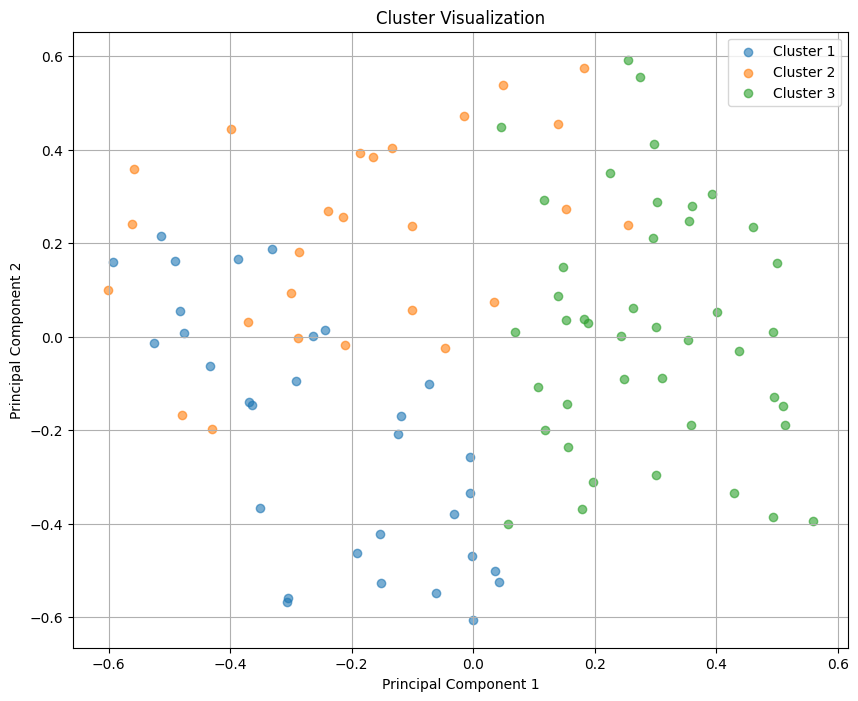

In [47]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def visualize_clusters(X, responsibilities, num_clusters):
    """
    Visualizes the clusters in 2D using PCA.

    Parameters:
        X (numpy.ndarray): The dataset of shape (n_samples, n_features).
        responsibilities (numpy.ndarray): Responsibilities for each cluster (n_samples, num_clusters).
        num_clusters (int): The number of clusters.

    Returns:
        None
    """
    # Reduce data to 2D for visualization using PCA
    pca = PCA(n_components=2)
    X_reduced = pca.fit_transform(X)

    # Assign each point to the cluster with the highest responsibility
    cluster_assignments = responsibilities.argmax(axis=1)

    # Plot each cluster
    plt.figure(figsize=(10, 8))
    for cluster in range(num_clusters):
        cluster_points = X_reduced[cluster_assignments == cluster]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster + 1}', alpha=0.6)

    # Add labels and legend
    plt.title("Cluster Visualization")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend()
    plt.grid()
    plt.show()

# Call the function to visualize clusters
visualize_clusters(X, final_responsibilities, num_clusters)


In [50]:
print("Shape of X:", X.shape)  # Check the number of features in X
print("Columns specified:", ['x', 'y', 'xVelocity', 'yVelocity', 'xAcceleration', 'yAcceleration'])  # Check expected columns


Shape of X: (100, 3)
Columns specified: ['x', 'y', 'xVelocity', 'yVelocity', 'xAcceleration', 'yAcceleration']


In [49]:
def visualize_2d_clusters(X, responsibilities, num_clusters, features=['xAcceleration', 'yVelocity']):
    """
    Visualizes clusters in 2D using selected features (with PCA if necessary).

    Parameters:
        X (pandas.DataFrame or numpy.ndarray): The dataset of shape (n_samples, n_features).
        responsibilities (numpy.ndarray): Responsibilities for each cluster (n_samples, num_clusters).
        num_clusters (int): The number of clusters.
        features (list): List of features to use for 2D visualization.

    Returns:
        None
    """
    # Extract only the features we want to visualize
    X_selected = X[features].values if isinstance(X, pd.DataFrame) else X[:, :2]  # Use first two features if numpy array

    # Assign each point to the cluster with the highest responsibility
    cluster_assignments = responsibilities.argmax(axis=1)

    # Plot the clusters
    plt.figure(figsize=(10, 8))
    for cluster in range(num_clusters):
        cluster_points = X_selected[cluster_assignments == cluster]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster + 1}', alpha=0.6)

    plt.title("2D Cluster Visualization (Acceleration & Velocity)")
    plt.xlabel(features[0])
    plt.ylabel(features[1])
    plt.legend()
    plt.grid()
    plt.show()

# Call the function for 2D visualization
visualize_2d_clusters(pd.DataFrame(X, columns=['x', 'y', 'xVelocity', 'yVelocity', 'xAcceleration', 'yAcceleration']),
                      final_responsibilities, num_clusters, features=['xAcceleration', 'xVelocity'])


ValueError: Shape of passed values is (100, 3), indices imply (100, 6)